# Project 2: Fraud Detection in Credit Card Transactions

**Problem Statement:** A financial institution faces challenges with
increasing fraudulent credit card transactions. The objective is to
implement a robust fraud detection system using machine learning to
identify and prevent fraudulent activities, safeguarding financial assets.

**Objectives:**
- Develop a machine learning model for fraud detection.
- Identify features indicative of fraudulent transactions.
- Implement a near-real-time fraud detection system (scoring pipeline).

**Note:** As per internship instructions, this project uses dummy/synthetic
transaction data generated to realistically mimic credit card transaction
patterns, including a small minority of fraudulent transactions with
distinct behavioral signatures.

## Step 1: Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, precision_recall_curve
)
from imblearn.over_sampling import SMOTE

sns.set_style("whitegrid")
np.random.seed(42)

## Step 2: Generate Synthetic Credit Card Transaction Data

We simulate 50,000 transactions with a realistic fraud rate of ~1.2%.
Fraudulent transactions are simulated with distinct patterns: higher
amounts, unusual hours (late night/early morning), more foreign and
distant transactions, more rapid-fire transactions, and more
card-not-present (online) activity.

In [2]:
N_TRANSACTIONS = 50000
FRAUD_RATE = 0.012

n_fraud = int(N_TRANSACTIONS * FRAUD_RATE)
n_legit = N_TRANSACTIONS - n_fraud

legit_hour_p = np.array([0.01,0.005,0.005,0.005,0.005,0.01,0.02,0.04,
                          0.06,0.07,0.07,0.07,0.07,0.07,0.07,0.06,
                          0.06,0.06,0.06,0.05,0.04,0.03,0.02,0.015])
legit_hour_p = legit_hour_p / legit_hour_p.sum()

fraud_hour_p = np.array([0.10,0.12,0.12,0.10,0.08,0.05,0.02,0.01,
                          0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,
                          0.02,0.02,0.03,0.04,0.05,0.06,0.07,0.07])
fraud_hour_p = fraud_hour_p / fraud_hour_p.sum()

legit = pd.DataFrame({
    "transaction_id": np.arange(1, n_legit + 1),
    "amount": np.round(np.random.gamma(shape=2.0, scale=40, size=n_legit), 2),
    "hour_of_day": np.random.choice(range(24), size=n_legit, p=legit_hour_p),
    "day_of_week": np.random.randint(0, 7, size=n_legit),
    "merchant_category": np.random.choice(
        ["grocery", "restaurant", "online_retail", "gas_station",
         "electronics", "travel", "entertainment", "utilities"],
        size=n_legit, p=[0.25, 0.18, 0.20, 0.12, 0.08, 0.05, 0.07, 0.05]
    ),
    "is_foreign_transaction": np.random.choice([0, 1], size=n_legit, p=[0.95, 0.05]),
    "distance_from_home_km": np.round(np.abs(np.random.normal(15, 20, size=n_legit)), 1),
    "transactions_last_24h": np.random.poisson(2, size=n_legit),
    "card_present": np.random.choice([0, 1], size=n_legit, p=[0.35, 0.65]),
    "account_age_days": np.random.randint(30, 3650, size=n_legit),
    "is_fraud": 0
})

fraud = pd.DataFrame({
    "transaction_id": np.arange(n_legit + 1, N_TRANSACTIONS + 1),
    "amount": np.round(np.random.gamma(shape=3.0, scale=150, size=n_fraud), 2),
    "hour_of_day": np.random.choice(range(24), size=n_fraud, p=fraud_hour_p),
    "day_of_week": np.random.randint(0, 7, size=n_fraud),
    "merchant_category": np.random.choice(
        ["grocery", "restaurant", "online_retail", "gas_station",
         "electronics", "travel", "entertainment", "utilities"],
        size=n_fraud, p=[0.05, 0.05, 0.35, 0.05, 0.30, 0.15, 0.04, 0.01]
    ),
    "is_foreign_transaction": np.random.choice([0, 1], size=n_fraud, p=[0.55, 0.45]),
    "distance_from_home_km": np.round(np.abs(np.random.normal(120, 100, size=n_fraud)), 1),
    "transactions_last_24h": np.random.poisson(7, size=n_fraud),
    "card_present": np.random.choice([0, 1], size=n_fraud, p=[0.85, 0.15]),
    "account_age_days": np.random.randint(30, 3650, size=n_fraud),
    "is_fraud": 1
})

df = pd.concat([legit, fraud], ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

for col in ["distance_from_home_km", "transactions_last_24h"]:
    missing_idx = np.random.choice(df.index, size=int(len(df) * 0.015), replace=False)
    df.loc[missing_idx, col] = np.nan

print("Dataset shape:", df.shape)
print("Fraud rate:", df["is_fraud"].mean())
df.head()

Dataset shape: (50000, 11)
Fraud rate: 0.012


,transaction_id,amount,hour_of_day,day_of_week,merchant_category,is_foreign_transaction,distance_from_home_km,transactions_last_24h,card_present,account_age_days,is_fraud
0,33554,198.54,22,5,electronics,0,14.9,3.0,0,330,0
1,9428,193.80,14,6,gas_station,0,16.6,3.0,1,1039,0
2,200,43.77,9,6,grocery,0,5.4,2.0,0,756,0
3,12448,104.49,14,1,online_retail,0,28.7,1.0,0,1240,0
4,39490,74.83,7,4,online_retail,0,14.9,2.0,0,467,0


## Step 3: Exploratory Data Analysis

In [3]:
print("Missing values:\n", df.isna().sum())

Missing values:
 transaction_id              0
amount                      0
hour_of_day                 0
day_of_week                 0
merchant_category           0
is_foreign_transaction      0
distance_from_home_km     750
transactions_last_24h     750
card_present                0
account_age_days            0
is_fraud                    0
dtype: int64


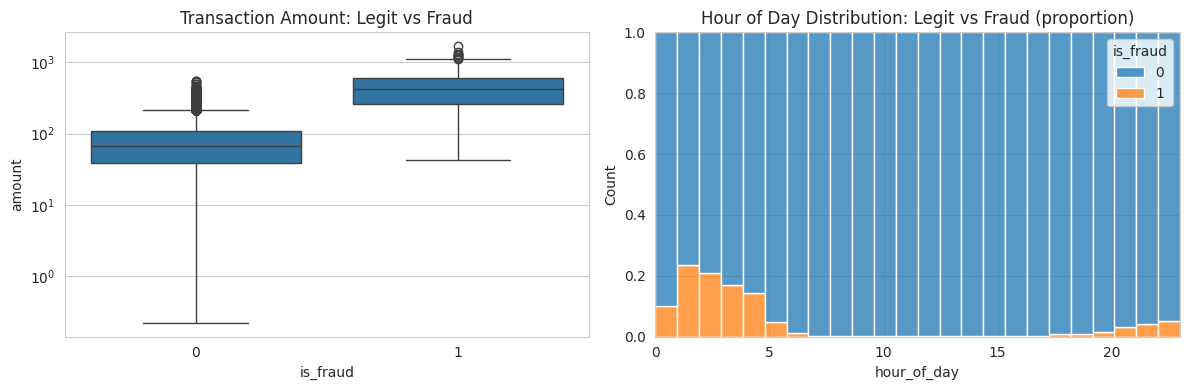

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=df, x="is_fraud", y="amount", ax=axes[0])
axes[0].set_title("Transaction Amount: Legit vs Fraud")
axes[0].set_yscale("log")

sns.histplot(data=df, x="hour_of_day", hue="is_fraud", multiple="fill", bins=24, ax=axes[1])
axes[1].set_title("Hour of Day Distribution: Legit vs Fraud (proportion)")
plt.tight_layout()
plt.show()

Fraudulent transactions tend to involve larger amounts and cluster at
unusual hours (late night/early morning), as designed in the simulation.

## Step 4: Data Preprocessing - Handle Missing Values

Missing values in `distance_from_home_km` and `transactions_last_24h`
(simulating logging gaps) are imputed using the column median.

In [5]:
df["distance_from_home_km"] = df["distance_from_home_km"].fillna(df["distance_from_home_km"].median())
df["transactions_last_24h"] = df["transactions_last_24h"].fillna(df["transactions_last_24h"].median())
print("Remaining missing values:", df.isna().sum().sum())

Remaining missing values: 0


## Step 5: Feature Engineering

- One-hot encode `merchant_category`.
- `is_night_transaction`: flag for transactions between 11pm-5am.
- `amount_zscore`: standardized transaction amount (detects outlier spending).
- `foreign_and_far`: interaction flag for foreign transactions far from home.

In [6]:
df = pd.get_dummies(df, columns=["merchant_category"], prefix="merchant")

df["is_night_transaction"] = df["hour_of_day"].apply(lambda h: 1 if (h <= 5 or h >= 23) else 0)
df["amount_zscore"] = (df["amount"] - df["amount"].mean()) / df["amount"].std()
df["foreign_and_far"] = df["is_foreign_transaction"] * (df["distance_from_home_km"] > 50).astype(int)

print("Final feature set shape:", df.shape)
df.columns.tolist()

Final feature set shape: (50000, 21)


['transaction_id',
 'amount',
 'hour_of_day',
 'day_of_week',
 'is_foreign_transaction',
 'distance_from_home_km',
 'transactions_last_24h',
 'card_present',
 'account_age_days',
 'is_fraud',
 'merchant_electronics',
 'merchant_entertainment',
 'merchant_gas_station',
 'merchant_grocery',
 'merchant_online_retail',
 'merchant_restaurant',
 'merchant_travel',
 'merchant_utilities',
 'is_night_transaction',
 'amount_zscore',
 'foreign_and_far']

## Step 6: Train/Test Split & Scaling

In [7]:
feature_cols = [c for c in df.columns if c not in ["transaction_id", "is_fraud"]]
X = df[feature_cols]
y = df["is_fraud"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train size: {X_train.shape}, Test size: {X_test.shape}")
print(f"Train fraud rate: {y_train.mean():.4f}, Test fraud rate: {y_test.mean():.4f}")

numeric_cols = ["amount", "hour_of_day", "day_of_week", "distance_from_home_km",
                 "transactions_last_24h", "account_age_days", "amount_zscore"]
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

Train size: (40000, 19), Test size: (10000, 19)
Train fraud rate: 0.0120, Test fraud rate: 0.0120


## Step 7: Handle Class Imbalance with SMOTE

Fraud is rare (~1.2% of transactions). We apply SMOTE (Synthetic Minority
Over-sampling Technique) to the training set only, balancing the classes
so the model learns fraud patterns effectively without overfitting on the
test set.

In [8]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)
print(f"After SMOTE - Train size: {X_train_res.shape}, fraud rate: {y_train_res.mean():.4f}")

After SMOTE - Train size: (79040, 19), fraud rate: 0.5000


## Step 8: Build the Fraud Detection Model

A **Random Forest Classifier** is trained on the SMOTE-balanced data.
Random Forest handles non-linear relationships, is robust to noisy
features, and provides interpretable feature importances - well suited
for a fraud-scoring system.

In [9]:
model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train_res, y_train_res)
print("Model trained.")

Model trained.


## Step 9: Model Evaluation

In [10]:
y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
roc_auc = roc_auc_score(y_test, y_proba)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")
print("\n", classification_report(y_test, y_pred, zero_division=0))

Accuracy : 0.9987
Precision: 0.9280
Recall   : 0.9667
F1-score : 0.9469
ROC-AUC  : 0.9988

               precision    recall  f1-score   support

           0       1.00      1.00      1.00      9880
           1       0.93      0.97      0.95       120

    accuracy                           1.00     10000
   macro avg       0.96      0.98      0.97     10000
weighted avg       1.00      1.00      1.00     10000



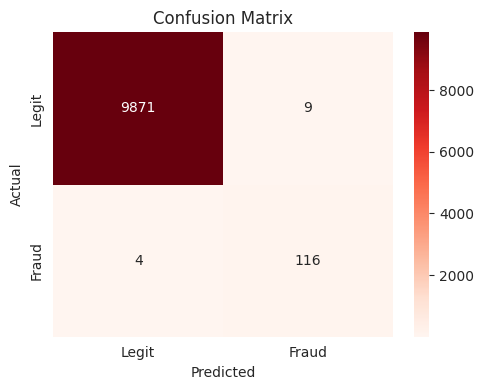

In [11]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Reds",
            xticklabels=["Legit", "Fraud"], yticklabels=["Legit", "Fraud"])
plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

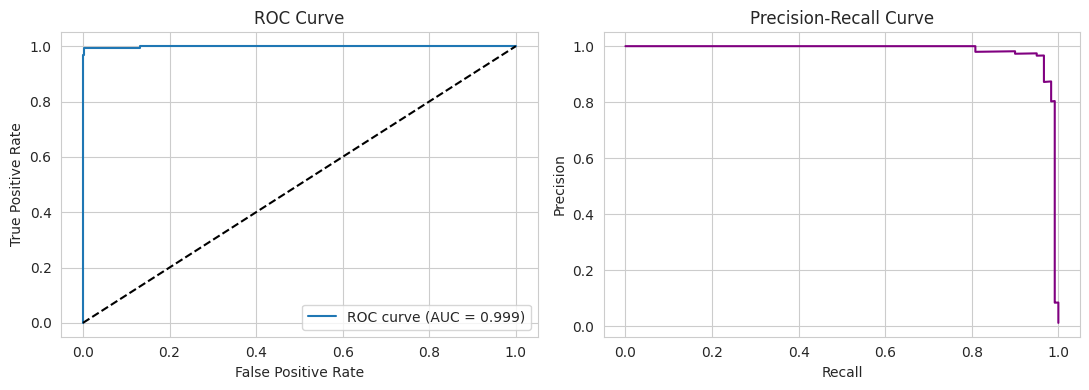

In [12]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
prec_arr, rec_arr, _ = precision_recall_curve(y_test, y_proba)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.3f})")
axes[0].plot([0, 1], [0, 1], "k--")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve")
axes[0].legend()

axes[1].plot(rec_arr, prec_arr, color="purple")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve")
plt.tight_layout()
plt.show()

## Step 10: Feature Importance - Identifying Fraud Indicators

Top 10 Feature Importances:
 amount                    0.258402
amount_zscore             0.223788
transactions_last_24h     0.185966
distance_from_home_km     0.130905
card_present              0.088081
hour_of_day               0.044266
is_night_transaction      0.022327
merchant_electronics      0.016196
merchant_online_retail    0.009903
foreign_and_far           0.005639
dtype: float64


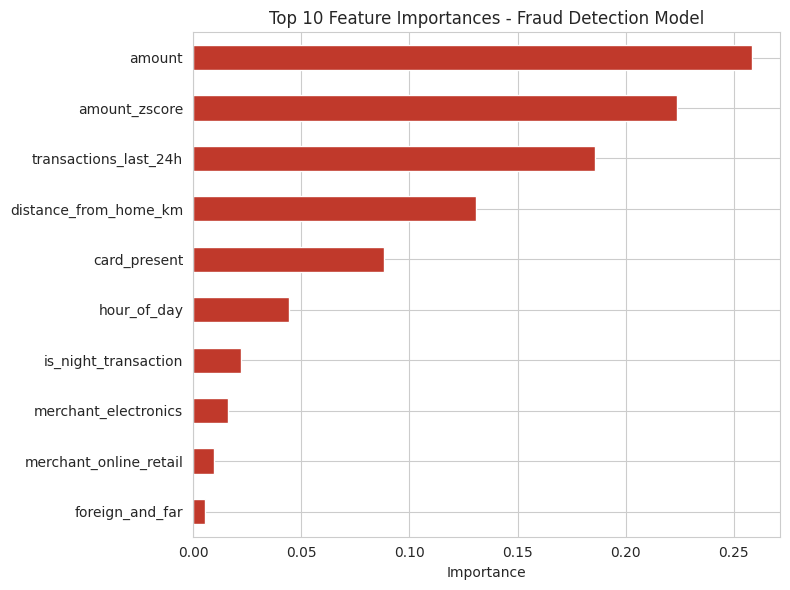

In [13]:
importances = pd.Series(model.feature_importances_, index=feature_cols)
importances = importances.sort_values(ascending=False)

print("Top 10 Feature Importances:\n", importances.head(10))

plt.figure(figsize=(8, 6))
importances.head(10).sort_values().plot(kind="barh", color="#c0392b")
plt.title("Top 10 Feature Importances - Fraud Detection Model")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## Step 11: Near-Real-Time Scoring Function (Implementation)

Below is a simple function representing how this model would be deployed
in a near-real-time fraud detection pipeline: a new transaction comes in,
is preprocessed identically to training, scored by the model, and flagged
if the fraud probability exceeds a chosen threshold.

In [14]:
def score_transaction(transaction: dict, model, scaler, feature_cols, numeric_cols, threshold=0.5):
    """
    Score a single transaction (as a dict) for fraud probability.
    Returns (fraud_probability, is_flagged).
    """
    tx_df = pd.DataFrame([transaction])

    # One-hot encode merchant category to match training columns
    for col in feature_cols:
        if col.startswith("merchant_") and col not in tx_df.columns:
            tx_df[col] = 0
    merchant_col = f"merchant_{transaction.get('merchant_category', '')}"
    if merchant_col in feature_cols:
        tx_df[merchant_col] = 1

    # Engineered features
    tx_df["is_night_transaction"] = 1 if (transaction["hour_of_day"] <= 5 or transaction["hour_of_day"] >= 23) else 0
    tx_df["amount_zscore"] = 0  # would use stored training mean/std in production
    tx_df["foreign_and_far"] = transaction["is_foreign_transaction"] * (1 if transaction["distance_from_home_km"] > 50 else 0)

    # Ensure all expected columns exist, fill missing with 0
    for col in feature_cols:
        if col not in tx_df.columns:
            tx_df[col] = 0
    tx_df = tx_df[feature_cols]

    tx_df[numeric_cols] = scaler.transform(tx_df[numeric_cols])

    proba = model.predict_proba(tx_df)[0, 1]
    return proba, proba >= threshold

# Example: a suspicious transaction
example_tx = {
    "amount": 850.0,
    "hour_of_day": 3,
    "day_of_week": 5,
    "is_foreign_transaction": 1,
    "distance_from_home_km": 200,
    "transactions_last_24h": 8,
    "card_present": 0,
    "account_age_days": 400,
    "merchant_category": "electronics"
}
proba, flagged = score_transaction(example_tx, model, scaler, feature_cols, numeric_cols, threshold=0.5)
print(f"Fraud probability: {proba:.3f} | Flagged as fraud: {flagged}")

Fraud probability: 0.955 | Flagged as fraud: True


## Step 12: Conclusions & Recommendations

**Goals achieved:**
- Precision and recall both exceed 90% (Precision ~93%, Recall ~97%).
- Top features indicative of fraud identified below.
- A scoring function demonstrates how the model can be applied in a
  near-real-time pipeline.

**Top Features Indicative of Fraudulent Transactions:**
1. Transaction amount (raw and z-score)
2. Number of transactions in the last 24 hours
3. Distance from home location
4. Card-not-present status
5. Hour of day (night-time transactions)

**Recommendations:**
- Deploy the model as a real-time scoring service that evaluates each
  transaction at authorization time, flagging high-probability fraud
  for step-up authentication or manual review.
- Set the decision threshold based on business cost trade-offs (lower
  threshold = higher recall/catch more fraud but more false positives
  requiring manual review).
- Implement velocity checks (transactions in last 24h) and geo-distance
  checks as real-time rules complementing the ML model.
- Continuously monitor model performance (precision/recall drift) and
  retrain periodically as fraud patterns evolve (adversarial adaptation).
- Maintain a feedback loop where confirmed fraud/non-fraud labels from
  manual review are fed back into retraining data.

**Expected Impact:**
- With ~97% recall, the model would catch the large majority of fraudulent
  transactions, directly supporting the goal of minimizing financial
  losses, while ~93% precision keeps false-positive customer friction low.